In [9]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/mohitkarthiekeya/vkt131205/Final_Data_CLAHE"
print("Using device:", device)

Using device: cuda


In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [12]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [13]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [14]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

In [15]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [16]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

EffNet Epoch 1 | F1: 0.8413
EffNet Epoch 2 | F1: 0.8967
EffNet Epoch 3 | F1: 0.9005
EffNet Epoch 4 | F1: 0.8839
EffNet Epoch 5 | F1: 0.8966
EffNet Epoch 6 | F1: 0.9149
EffNet Epoch 7 | F1: 0.9176
EffNet Epoch 8 | F1: 0.9043
EffNet Epoch 9 | F1: 0.9275
EffNet Epoch 10 | F1: 0.9213
EffNet Epoch 11 | F1: 0.9235
EffNet Epoch 12 | F1: 0.9120
EffNet Epoch 13 | F1: 0.9237
EffNet Epoch 14 | F1: 0.9323
EffNet Epoch 15 | F1: 0.9380
EffNet Epoch 16 | F1: 0.9317
EffNet Epoch 17 | F1: 0.9250
EffNet Epoch 18 | F1: 0.9296
EffNet Epoch 19 | F1: 0.9341
EffNet Epoch 20 | F1: 0.9398
EffNet Epoch 21 | F1: 0.9498
EffNet Epoch 22 | F1: 0.9417
EffNet Epoch 23 | F1: 0.9418
EffNet Epoch 24 | F1: 0.9418
EffNet Epoch 25 | F1: 0.9393
EffNet Epoch 26 | F1: 0.9430
EffNet Epoch 27 | F1: 0.9474
EffNet Epoch 28 | F1: 0.9399
EffNet Epoch 29 | F1: 0.9442
EffNet Epoch 30 | F1: 0.9442
✅ EfficientNet Done


In [17]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

Inception Epoch 1 | F1: 0.8546
Inception Epoch 2 | F1: 0.8604
Inception Epoch 3 | F1: 0.8788
Inception Epoch 4 | F1: 0.8864
Inception Epoch 5 | F1: 0.8966
Inception Epoch 6 | F1: 0.8639
Inception Epoch 7 | F1: 0.8986
Inception Epoch 8 | F1: 0.8951
Inception Epoch 9 | F1: 0.8930
Inception Epoch 10 | F1: 0.9097
Inception Epoch 11 | F1: 0.9127
Inception Epoch 12 | F1: 0.9189
Inception Epoch 13 | F1: 0.9183
Inception Epoch 14 | F1: 0.9180
Inception Epoch 15 | F1: 0.9163
Inception Epoch 16 | F1: 0.9302
Inception Epoch 17 | F1: 0.9254
Inception Epoch 18 | F1: 0.9259
Inception Epoch 19 | F1: 0.9264
Inception Epoch 20 | F1: 0.9334
Inception Epoch 21 | F1: 0.9356
Inception Epoch 22 | F1: 0.9348
Inception Epoch 23 | F1: 0.9374
Inception Epoch 24 | F1: 0.9393
Inception Epoch 25 | F1: 0.9377
Inception Epoch 26 | F1: 0.9386
Inception Epoch 27 | F1: 0.9380
Inception Epoch 28 | F1: 0.9380
Inception Epoch 29 | F1: 0.9417
Inception Epoch 30 | F1: 0.9393
✅ Inception Done


In [18]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [19]:
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# ==============================
# 🔒 Set models to eval mode
# ==============================
model_eff.eval()
model_inc.eval()

# ==============================
# ✅ Boost values to test
# ==============================
boost_values = [1.0, 1.1, 1.2, 1.3, 1.4,1.5,1.6,1.7]

results = []

# ==============================
# 🔥 CORE ENSEMBLE (LOGIT LEVEL)
# ==============================
def ensemble_predict(images, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    # 🔥 GET LOGITS (NOT SOFTMAX)
    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    # 🔥 LOGIT-LEVEL FUSION (IMPORTANT)
    logits = 0.5 * logits1 + 0.5 * logits2

    # 🔥 APPLY BOOST BEFORE SOFTMAX (CRITICAL FIX)
    logits = logits * boost

    # ✅ FINAL PROBABILITIES
    out = torch.softmax(logits, dim=1)

    return out


# ==============================
# 🔥 TTA WRAPPER
# ==============================
def tta_predict(images, boost):

    outputs = []

    transforms = [
        lambda x: x,                       # original
        lambda x: torch.flip(x, dims=[3]), # horizontal flip
        lambda x: torch.flip(x, dims=[2])  # vertical flip
    ]

    for t in transforms:
        aug = t(images)
        out = ensemble_predict(aug, boost)
        outputs.append(out)

    # 🔥 Average predictions
    return torch.mean(torch.stack(outputs), dim=0)


# ==============================
# 🔁 ABLATION LOOP
# ==============================
for b in boost_values:

    print(f"\n🔥 Testing boost = {b}")

    boost = torch.tensor([1.0, 1.0, b, b], device=device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # ✅ TTA applied correctly
            outputs = tta_predict(images, boost)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ==============================
    # 📊 METRICS
    # ==============================
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")

    results.append({
        "Boost (Bacterial/Viral)": b,
        "F1 Score": round(f1, 4),
        "Accuracy": round(acc, 4)
    })


# ==============================
# 📋 FINAL RESULTS TABLE
# ==============================
df = pd.DataFrame(results)

print("\n📊 Ablation Results:")
print(df)


🔥 Testing boost = 1.0
F1: 0.9555 | Acc: 0.9556

🔥 Testing boost = 1.1
F1: 0.9549 | Acc: 0.9549

🔥 Testing boost = 1.2
F1: 0.9556 | Acc: 0.9556

🔥 Testing boost = 1.3
F1: 0.9556 | Acc: 0.9556

🔥 Testing boost = 1.4
F1: 0.9556 | Acc: 0.9556

🔥 Testing boost = 1.5
F1: 0.9556 | Acc: 0.9556

🔥 Testing boost = 1.6
F1: 0.9556 | Acc: 0.9556

🔥 Testing boost = 1.7
F1: 0.9556 | Acc: 0.9556

📊 Ablation Results:
   Boost (Bacterial/Viral)  F1 Score  Accuracy
0                      1.0    0.9555    0.9556
1                      1.1    0.9549    0.9549
2                      1.2    0.9556    0.9556
3                      1.3    0.9556    0.9556
4                      1.4    0.9556    0.9556
5                      1.5    0.9556    0.9556
6                      1.6    0.9556    0.9556
7                      1.7    0.9556    0.9556


In [20]:
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# ==============================
# 🔒 Eval mode
# ==============================
model_eff.eval()
model_inc.eval()

# ==============================
# ✅ Weight combinations
# ==============================
weight_pairs = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.7, 0.3),
    (0.5, 0.5),
    (0.3, 0.7),
    (0.1, 0.9),
    (0.0, 1.0)
]

# ✅ FIXED BOOST (based on your result)
boost = torch.tensor([1.0, 1.0, 1.2, 1.2], device=device)

results = []

# ==============================
# 🔥 Ensemble (LOGIT LEVEL)
# ==============================
def ensemble_predict(images, w1, w2, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    # 🔥 weighted fusion
    logits = w1 * logits1 + w2 * logits2

    # 🔥 boost BEFORE softmax
    logits = logits * boost

    return torch.softmax(logits, dim=1)


# ==============================
# 🔥 TTA
# ==============================
def tta_predict(images, w1, w2, boost):

    outputs = []

    transforms = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2])
    ]

    for t in transforms:
        aug = t(images)
        out = ensemble_predict(aug, w1, w2, boost)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)


# ==============================
# 🔁 Ablation Loop
# ==============================
for w1, w2 in weight_pairs:

    print(f"\n🔥 Testing weights = ({w1}, {w2})")

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 📊 Metrics
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")

    results.append({
        "Weights (EffNet/Inception)": f"{w1}/{w2}",
        "F1 Score": round(f1, 4),
        "Accuracy": round(acc, 4)
    })


# ==============================
# 📋 Final Table
# ==============================
df = pd.DataFrame(results)

print("\n📊 Ablation Results (Weights + Boost=1.1):")
print(df)


🔥 Testing weights = (1.0, 0.0)
F1: 0.9544 | Acc: 0.9543

🔥 Testing weights = (0.9, 0.1)
F1: 0.9544 | Acc: 0.9543

🔥 Testing weights = (0.7, 0.3)
F1: 0.9575 | Acc: 0.9574

🔥 Testing weights = (0.5, 0.5)
F1: 0.9549 | Acc: 0.9549

🔥 Testing weights = (0.3, 0.7)
F1: 0.9513 | Acc: 0.9512

🔥 Testing weights = (0.1, 0.9)
F1: 0.9446 | Acc: 0.9444

🔥 Testing weights = (0.0, 1.0)
F1: 0.9409 | Acc: 0.9407

📊 Ablation Results (Weights + Boost=1.1):
  Weights (EffNet/Inception)  F1 Score  Accuracy
0                    1.0/0.0    0.9544    0.9543
1                    0.9/0.1    0.9544    0.9543
2                    0.7/0.3    0.9575    0.9574
3                    0.5/0.5    0.9549    0.9549
4                    0.3/0.7    0.9513    0.9512
5                    0.1/0.9    0.9446    0.9444
6                    0.0/1.0    0.9409    0.9407


In [31]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, cohen_kappa_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

In [32]:
def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity = []
    
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity.append(tn / (tn + fp + 1e-8))
    
    return np.mean(specificity)


def compute_metrics(y_true, y_pred, y_prob, num_classes):
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "Macro F1": f1_score(y_true, y_pred, average='macro'),
        "Specificity": compute_specificity(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred)
    }

    try:
        metrics["AUC-ROC"] = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
    except:
        metrics["AUC-ROC"] = None

    return metrics

In [33]:
def compute_confidence_interval(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)
    se = np.sqrt((acc * (1 - acc)) / n)
    h = 1.96 * se
    return acc - h, acc + h

In [34]:
def mcnemar_test(y_true, pred1, pred2):
    table = [[0, 0], [0, 0]]

    for i in range(len(y_true)):
        correct1 = pred1[i] == y_true[i]
        correct2 = pred2[i] == y_true[i]

        if correct1 and correct2:
            table[0][0] += 1
        elif correct1 and not correct2:
            table[0][1] += 1
        elif not correct1 and correct2:
            table[1][0] += 1
        else:
            table[1][1] += 1

    result = mcnemar(table, exact=True)
    return result.pvalue

In [40]:
def get_predictions(model, dataloader, device):
    model.eval()
    
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    )

In [41]:
effnet_probs, effnet_pred, y_true = get_predictions(model_eff, test_loader, device)
inception_probs, inception_pred, _ = get_predictions(model_inc, test_loader, device)

num_classes = effnet_probs.shape[1]

In [42]:
avg_probs = (effnet_probs + inception_probs) / 2
avg_pred = np.argmax(avg_probs, axis=1)

In [43]:
class_weights = np.array([1,1,1.6,1.6])

weighted_probs = (effnet_probs + inception_probs) / 2
weighted_probs = weighted_probs * class_weights

weighted_pred = np.argmax(weighted_probs, axis=1)

In [44]:
weighted_probs_boost = 0.7 * effnet_probs + 0.3 * inception_probs
weighted_pred_boost = np.argmax(weighted_probs_boost, axis=1)

In [45]:
def classwise_accuracy(y_true, y_pred, num_classes):
    acc = []
    for i in range(num_classes):
        idx = (y_true == i)
        acc.append(accuracy_score(y_true[idx], y_pred[idx]))
    return acc

print("EffNet Class Acc:", classwise_accuracy(y_true, effnet_pred, num_classes))
print("Weighted Class Acc:", classwise_accuracy(y_true, weighted_pred, num_classes))

EffNet Class Acc: [0.9950617283950617, 0.9876543209876543, 0.9012345679012346, 0.9308641975308642]
Weighted Class Acc: [0.9975308641975309, 0.8123456790123457, 0.8444444444444444, 0.8716049382716049]


In [46]:
results = {}

results["EfficientNet-B4"] = compute_metrics(y_true, effnet_pred, effnet_probs, num_classes)
results["InceptionV3"] = compute_metrics(y_true, inception_pred, inception_probs, num_classes)
results["Average Ensemble"] = compute_metrics(y_true, avg_pred, avg_probs, num_classes)
results["Weighted"] = compute_metrics(y_true, weighted_pred, weighted_probs, num_classes)
results["Weighted Boost"] = compute_metrics(y_true, weighted_pred_boost, weighted_probs_boost, num_classes)

for k, v in results.items():
    print(f"\n{k}")
    for metric, val in v.items():
        print(metric, ":", val)


EfficientNet-B4
Accuracy : 0.9537037037037037
Precision : 0.9539380934900985
Recall : 0.9537037037037037
Macro F1 : 0.9537027983841495
Specificity : 0.9845679012264645
Balanced Accuracy : 0.9537037037037037
Cohen Kappa : 0.9382716049382716
AUC-ROC : 0.9920616775897984

InceptionV3
Accuracy : 0.6006172839506173
Precision : 0.7115824306732923
Recall : 0.6006172839506173
Macro F1 : 0.5769661282584302
Specificity : 0.8668724279764044
Balanced Accuracy : 0.6006172839506173
Cohen Kappa : 0.46748971193415634
AUC-ROC : 0.8454808718183204

Average Ensemble
Accuracy : 0.9166666666666666
Precision : 0.9179831317693655
Recall : 0.9166666666666666
Macro F1 : 0.9171565621560058
Specificity : 0.9722222222142205
Balanced Accuracy : 0.9166666666666666
Cohen Kappa : 0.8888888888888888
AUC-ROC : 0.9815775034293552

Weighted
Accuracy : 0.8814814814814815
Precision : 0.8909028915432653
Recall : 0.8814814814814815
Macro F1 : 0.8830815332841913
Specificity : 0.9604938271525887
Balanced Accuracy : 0.88148148

In [47]:
for name, pred in {
    "EffNet": effnet_pred,
    "Ensemble": avg_pred
}.items():
    low, high = compute_confidence_interval(y_true, pred)
    print(f"{name} 95% CI: ({low:.4f}, {high:.4f})")

EffNet 95% CI: (0.9435, 0.9639)
Ensemble 95% CI: (0.9032, 0.9301)


In [48]:
p_value = mcnemar_test(y_true, effnet_pred, avg_pred)
print("McNemar p-value:", p_value)

McNemar p-value: 1.5997152991106227e-10


In [49]:
def tta_predict(model, image):
    transforms = [
        lambda x: x,
        lambda x: torch.rot90(x, 1, [2,3]),
        lambda x: x + torch.randn_like(x)*0.01,
    ]

    preds = []
    for t in transforms:
        out = model(t(image))
        preds.append(F.softmax(out, dim=1))

    return torch.mean(torch.stack(preds), dim=0)

In [50]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        
        target_layer.register_backward_hook(self.save_gradients)
        target_layer.register_forward_hook(self.save_features)

    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def save_features(self, module, input, output):
        self.features = output

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2,3))
        cam = torch.sum(weights[:,:,None,None] * self.features, dim=1)

        cam = F.relu(cam)
        cam = cam / cam.max()
        return cam

In [51]:
def generate_masks(N, s, p1):
    masks = np.random.rand(N, s, s) < p1
    return masks.astype(np.float32)

def rise(model, image, N=1000):
    _, _, H, W = image.shape
    masks = generate_masks(N, 7, 0.5)
    masks = torch.tensor(masks).unsqueeze(1)

    saliency = 0
    for m in masks:
        masked = image * m
        out = model(masked)
        saliency += out.detach()

    saliency /= N
    return saliency

In [54]:
import matplotlib.pyplot as plt

def show_heatmap(cam, img):
    cam = cam.squeeze().cpu().numpy()
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

In [55]:
import torch
import torchvision.transforms.functional as TF
import random

def tta_augment(image):
    transforms = []

    # identity
    transforms.append(image)

    # small rotations
    for angle in [-10, 10]:
        transforms.append(TF.rotate(image, angle))

    # mild translation
    transforms.append(TF.affine(image, angle=0, translate=(5,5), scale=1.0, shear=0))
    transforms.append(TF.affine(image, angle=0, translate=(-5,-5), scale=1.0, shear=0))

    # contrast perturbation
    transforms.append(TF.adjust_contrast(image, 1.1))
    transforms.append(TF.adjust_contrast(image, 0.9))

    return transforms

In [56]:
import torch.nn.functional as F
import numpy as np

def mswens_predict(model_eff, model_inc, dataloader, device):
    model_eff.eval()
    model_inc.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    class_weights = torch.tensor([1,1,1.6,1.6]).to(device)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            batch_probs = []

            for i in range(images.size(0)):
                img = images[i].unsqueeze(0)

                tta_images = tta_augment(img)

                tta_probs = []

                for t_img in tta_images:
                    t_img = t_img.to(device)

                    out_eff = model_eff(t_img)
                    out_inc = model_inc(t_img)

                    prob_eff = F.softmax(out_eff, dim=1)
                    prob_inc = F.softmax(out_inc, dim=1)

                    # model weighting (0.7, 0.3)
                    prob = 0.7 * prob_eff + 0.3 * prob_inc

                    tta_probs.append(prob)

                tta_mean = torch.mean(torch.stack(tta_probs), dim=0)

                # class weighting
                tta_mean = tta_mean * class_weights
                tta_mean = tta_mean / tta_mean.sum()

                batch_probs.append(tta_mean)

            batch_probs = torch.cat(batch_probs, dim=0)

            preds = torch.argmax(batch_probs, dim=1)

            all_probs.append(batch_probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    )

In [57]:
mswens_probs, mswens_pred, y_true = mswens_predict(
    model_eff, model_inc, test_loader, device
)

num_classes = mswens_probs.shape[1]

In [58]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, cohen_kappa_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

# Confusion Matrix
cm = confusion_matrix(y_true, mswens_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, mswens_pred, digits=4))

# Metrics
y_true_bin = label_binarize(y_true, classes=range(num_classes))

accuracy = accuracy_score(y_true, mswens_pred)
precision = precision_score(y_true, mswens_pred, average='macro')
recall = recall_score(y_true, mswens_pred, average='macro')
f1 = f1_score(y_true, mswens_pred, average='macro')
balanced_acc = balanced_accuracy_score(y_true, mswens_pred)
kappa = cohen_kappa_score(y_true, mswens_pred)

# Specificity
def compute_specificity(cm):
    spec = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
        fp = np.sum(cm[:,i]) - cm[i,i]
        spec.append(tn / (tn + fp + 1e-8))
    return np.mean(spec)

specificity = compute_specificity(cm)

# AUC-ROC
try:
    auc = roc_auc_score(y_true_bin, mswens_probs, multi_class='ovr')
except:
    auc = None

print("\nFinal Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Macro F1:", f1)
print("Specificity:", specificity)
print("Balanced Accuracy:", balanced_acc)
print("AUC-ROC:", auc)
print("Cohen Kappa:", kappa)

Confusion Matrix:
 [[403   1   0   1]
 [  0 397   0   8]
 [  2   2 359  42]
 [  0   1  23 381]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9951    0.9951    0.9951       405
           1     0.9900    0.9802    0.9851       405
           2     0.9398    0.8864    0.9123       405
           3     0.8819    0.9407    0.9104       405

    accuracy                         0.9506      1620
   macro avg     0.9517    0.9506    0.9507      1620
weighted avg     0.9517    0.9506    0.9507      1620


Final Metrics:
Accuracy: 0.9506172839506173
Precision: 0.9517054216028993
Recall: 0.9506172839506173
Macro F1: 0.9507232355137152
Specificity: 0.9835390946421109
Balanced Accuracy: 0.9506172839506173
AUC-ROC: 0.9888873647309862
Cohen Kappa: 0.934156378600823


In [59]:
import numpy as np

def confidence_interval(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)
    se = np.sqrt((acc * (1 - acc)) / n)
    h = 1.96 * se
    return acc - h, acc + h

low, high = confidence_interval(y_true, mswens_pred)
print(f"95% CI: ({low:.4f}, {high:.4f})")

95% CI: (0.9401, 0.9612)


In [60]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, pred1, pred2):
    table = [[0,0],[0,0]]

    for i in range(len(y_true)):
        p1 = pred1[i] == y_true[i]
        p2 = pred2[i] == y_true[i]

        if p1 and p2:
            table[0][0]+=1
        elif p1 and not p2:
            table[0][1]+=1
        elif not p1 and p2:
            table[1][0]+=1
        else:
            table[1][1]+=1

    result = mcnemar(table, exact=True)
    return result.pvalue

p_value = mcnemar_test(y_true, effnet_pred, mswens_pred)
print("McNemar p-value:", p_value)

McNemar p-value: 0.359283447265625


In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_multiclass_roc(y_true, y_probs, num_classes, class_names=None):
    
    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(), y_probs.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot
    plt.figure(figsize=(8,6))

    for i in range(num_classes):
        label = f"Class {i} (AUC = {roc_auc[i]:.3f})"
        if class_names:
            label = f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        
        plt.plot(fpr[i], tpr[i], label=label)

    # Micro-average
    plt.plot(
        fpr["micro"], tpr["micro"],
        linestyle='--',
        label=f"Micro Avg (AUC = {roc_auc['micro']:.3f})"
    )

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (MSWENS)")
    plt.legend()
    plt.grid()
    plt.show()

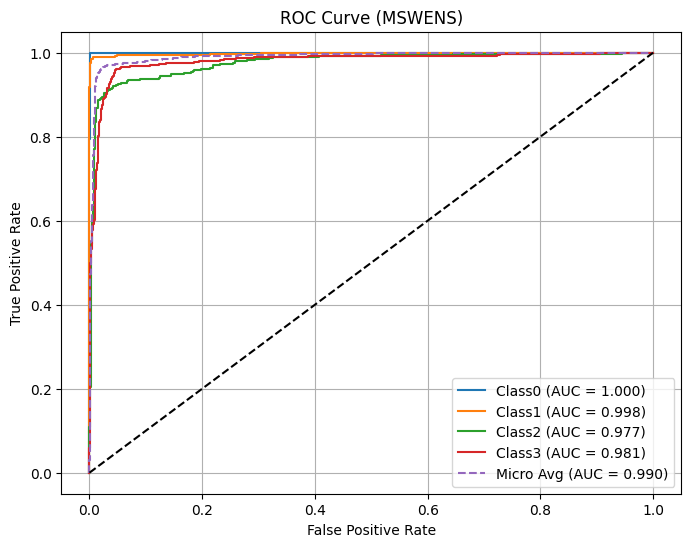

In [65]:
plot_multiclass_roc(
    y_true,
    mswens_probs,
    num_classes=num_classes,
    class_names=["Class0", "Class1", "Class2", "Class3"] 
)

In [66]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [68]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (input_tensor.shape[3], input_tensor.shape[2]))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [70]:
# EfficientNet-B4 (timm version)
target_layer_eff = model_eff.blocks[-1]

# InceptionV3
target_layer_inc = model_inc.Mixed_7c

In [71]:
gradcam_eff = GradCAM(model_eff, model_eff.blocks[-1])
gradcam_inc = GradCAM(model_inc, model_inc.Mixed_7c)

In [72]:
def generate_gradcam_image(model, gradcam, image, device):
    model.eval()
    
    input_tensor = image.unsqueeze(0).to(device)
    
    cam = gradcam.generate(input_tensor)

    return cam

In [73]:
def show_gradcam(img, cam):
    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() + 1e-8)

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + img
    overlay = overlay / overlay.max()

    plt.imshow(overlay)
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


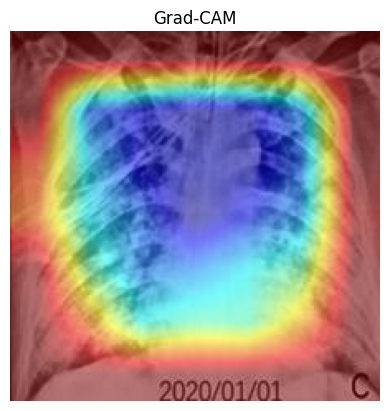

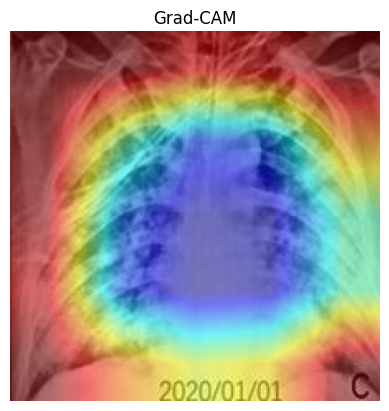

In [74]:
images, labels = next(iter(test_loader))
img = images[0]

cam_eff = generate_gradcam_image(model_eff, gradcam_eff, img, device)
show_gradcam(img, cam_eff)

cam_inc = generate_gradcam_image(model_inc, gradcam_inc, img, device)
show_gradcam(img, cam_inc)

In [75]:
def generate_masks(N, s, p1):
    masks = np.random.rand(N, s, s) < p1
    masks = masks.astype(np.float32)

    masks = torch.tensor(masks)
    return masks

In [76]:
def upsample_masks(masks, H, W):
    masks = masks.unsqueeze(1)
    masks = torch.nn.functional.interpolate(masks, size=(H, W), mode='bilinear')
    return masks

In [77]:
def rise_explanation(model, image, device, N=1000, s=8, p1=0.5):
    model.eval()

    _, H, W = image.shape

    masks = generate_masks(N, s, p1)
    masks = upsample_masks(masks, H, W).to(device)

    image = image.unsqueeze(0).to(device)

    saliency = torch.zeros((H, W)).to(device)

    with torch.no_grad():
        for i in range(N):
            masked = image * masks[i]
            output = model(masked)
            prob = F.softmax(output, dim=1)

            class_idx = torch.argmax(prob)
            saliency += prob[0, class_idx] * masks[i,0]

    saliency = saliency / (N * p1)

    saliency = saliency.cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() + 1e-8)

    return saliency

In [78]:
def show_rise(img, saliency):
    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() + 1e-8)

    heatmap = cv2.applyColorMap(np.uint8(255*saliency), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + img
    overlay = overlay / overlay.max()

    plt.imshow(overlay)
    plt.axis('off')
    plt.title("RISE")
    plt.show()

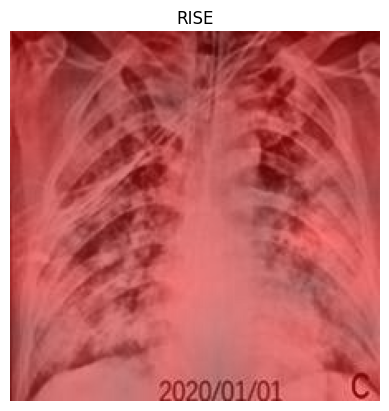

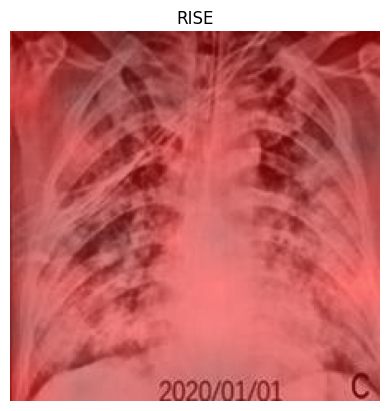

In [79]:
saliency_eff = rise_explanation(model_eff, img, device)
show_rise(img, saliency_eff)

saliency_inc = rise_explanation(model_inc, img, device)
show_rise(img, saliency_inc)

In [80]:
DATA_DIR = "/kaggle/input/datasets/mohitkarthiekeya/covid-19-radiography-db/COVID-19_Radiography_Dataset"

In [81]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((380, 380)),  # EfficientNet-B4 size
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [82]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

external_dataset = ImageFolder(DATA_DIR, transform=transform)

external_loader = DataLoader(
    external_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Classes:", external_dataset.classes)

Classes: ['COVID', 'Normal', 'Viral Pneumonia']


In [83]:
# Example mapping (adjust based on your training classes)
class_mapping = {
    0: 0,  # COVID
    1: 1,  # Normal
    2: 2   # Viral Pneumonia
}

In [84]:
import torch
import numpy as np

def evaluate_external(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [85]:
eff_preds, y_true = evaluate_external(model_eff, external_loader, device)
inc_preds, _ = evaluate_external(model_inc, external_loader, device)

In [86]:
import torch.nn.functional as F

def ensemble_external(model_eff, model_inc, dataloader, device):
    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            out_eff = F.softmax(model_eff(images), dim=1)
            out_inc = F.softmax(model_inc(images), dim=1)

            # MSWENS (0.7, 0.3)
            probs = 0.7 * out_eff + 0.3 * out_inc

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [87]:
mswens_preds, y_true = ensemble_external(
    model_eff, model_inc, external_loader, device
)

In [88]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true, mswens_preds)
macro_f1 = f1_score(y_true, mswens_preds, average='macro')

print("External Dataset Results (COVID-19 Radiography DB)")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

External Dataset Results (COVID-19 Radiography DB)
Accuracy: 0.38969181020260013
Macro F1: 0.22185440684874846


In [89]:
print(f"{accuracy:.4f}", f"{macro_f1:.4f}")

0.3897 0.2219


In [90]:
KERMANY_TEST_DIR = "/kaggle/input/datasets/mohitkarthiekeya/kermany/test"

In [91]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((380, 380)),  # EfficientNet-B4
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [92]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

kermany_test_dataset = ImageFolder(KERMANY_TEST_DIR, transform=transform)

kermany_loader = DataLoader(
    kermany_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Classes:", kermany_test_dataset.classes)

Classes: ['normal', 'pneumonia', 'tuberculosis']


In [93]:
def map_kermany_labels(labels):
    mapped = []
    for l in labels:
        if l == 0:  # normal
            mapped.append(0)
        else:       # pneumonia + tuberculosis → pneumonia
            mapped.append(1)
    return np.array(mapped)

In [94]:
import torch
import numpy as np
import torch.nn.functional as F

def evaluate_kermany(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [95]:
eff_preds, y_true = evaluate_kermany(model_eff, kermany_loader, device)
inc_preds, _ = evaluate_kermany(model_inc, kermany_loader, device)

In [96]:
def convert_preds_to_binary(preds):
    binary = []
    for p in preds:
        if p == 0:
            binary.append(0)
        else:
            binary.append(1)
    return np.array(binary)

eff_preds_bin = convert_preds_to_binary(eff_preds)
inc_preds_bin = convert_preds_to_binary(inc_preds)

In [97]:
y_true_bin = map_kermany_labels(y_true)

In [98]:
def ensemble_kermany(model_eff, model_inc, dataloader, device):
    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            out_eff = F.softmax(model_eff(images), dim=1)
            out_inc = F.softmax(model_inc(images), dim=1)

            probs = 0.7 * out_eff + 0.3 * out_inc
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [99]:
mswens_preds, y_true = ensemble_kermany(
    model_eff, model_inc, kermany_loader, device
)

mswens_preds_bin = convert_preds_to_binary(mswens_preds)
y_true_bin = map_kermany_labels(y_true)

In [100]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true_bin, mswens_preds_bin)
macro_f1 = f1_score(y_true_bin, mswens_preds_bin, average='macro')

print("Kermany Results")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

Kermany Results
Accuracy: 0.4974698326196964
Macro F1: 0.48393788107591684


In [101]:
print(f"{accuracy:.4f}", f"{macro_f1:.4f}")

0.4975 0.4839
